# Exploratory Data Analysis (EDA) for Instacart

**Goal:** Understand the dataset before building baskets and mining rules.

This notebook:
- Loads and inspects all tables: `orders`, `order_products__prior`, `order_products__train`,
  `products`, `aisles`, `departments`
- Checks data quality: missing values (explicit and implicit), duplicates, key consistency
- Studies product behavior: very frequent products vs rare items and outliers
- Studies customer behavior: heavy vs light buyers, basket sizes, reorder behavior
- Studies time patterns: which day and hour people buy the most
- Explores departments and aisles distributions to ensure good coverage before modeling

In [3]:
import numpy as np
import pandas as pd
from IPython.display import display
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
def load_instacart_tables():
    """
    Load Instacart tables from CSV files (same folder as the notebook).

    Returns
    -------
    dict
        Main Instacart tables.
    """
    tables = {
        "orders": pd.read_csv("../data/orders.csv"),
        "order_products__prior": pd.read_csv("../data/order_products__prior.csv"),
        "order_products__train": pd.read_csv("../data/order_products__train.csv"),
        "products": pd.read_csv("../data/products.csv"),
        "aisles": pd.read_csv("../data/aisles.csv"),
        "departments": pd.read_csv("../data/departments.csv"),
    }
    return tables


def enrich_products(products, aisles, departments):
    """
    Merge products with aisles and departments.

    Returns
    -------
    DataFrame
        Products with aisle and department names.
    """
    df = products.merge(aisles, on="aisle_id", how="left")
    df = df.merge(departments, on="department_id", how="left")
    return df


def overview_table(df, name):
    """
    Quick overview of a table.

    Returns
    -------
    DataFrame
        One row summary.
    """
    row = {
        "table": name,
        "rows": df.shape[0],
        "cols": df.shape[1],
        "missing_cells": int(df.isna().sum().sum()),
        "duplicate_rows": int(df.duplicated().sum()),
    }
    return pd.DataFrame([row])


def show_head(df, n=5):
    """
    Show the first n rows of a table.
    """
    display(df.head(n))


def missing_report(df, name, top_n=15):
    """
    Show the columns with the most missing values.

    Returns
    -------
    DataFrame
        Missing count and percentage per column.
    """
    miss = df.isna().sum().reset_index()
    miss.columns = ["column", "missing_count"]
    miss["missing_pct"] = miss["missing_count"] / len(df) if len(df) else 0.0
    miss["table"] = name
    miss = miss.sort_values("missing_count", ascending=False)
    return miss.head(top_n)[["table", "column", "missing_count", "missing_pct"]]


def implicit_missing_orders(orders):
    """
    Check implicit missingness for days_since_prior_order.
    Missing values are expected for first orders (order_number == 1).

    Returns
    -------
    DataFrame
        Counts explaining if missingness is normal.
    """
    ds_missing = orders["days_since_prior_order"].isna()
    first_order = orders["order_number"] == 1

    return pd.DataFrame([{
        "days_since_prior_missing": int(ds_missing.sum()),
        "first_orders": int(first_order.sum()),
        "missing_and_first": int((ds_missing & first_order).sum()),
        "missing_but_not_first": int((ds_missing & ~first_order).sum()),
    }])


def check_key_consistency(orders, op_prior, op_train, products):
    """
    Check if:
    - order_id in order_products exists in orders
    - product_id in order_products exists in products

    Returns
    -------
    DataFrame
        Missing key counts.
    """
    orders_set = set(orders["order_id"].unique())
    products_set = set(products["product_id"].unique())

    def count_missing(op):
        miss_orders = int((~op["order_id"].isin(orders_set)).sum())
        miss_products = int((~op["product_id"].isin(products_set)).sum())
        return miss_orders, miss_products

    p_mo, p_mp = count_missing(op_prior)
    t_mo, t_mp = count_missing(op_train)

    return pd.DataFrame([
        {"table": "order_products__prior", "missing_order_id": p_mo, "missing_product_id": p_mp},
        {"table": "order_products__train", "missing_order_id": t_mo, "missing_product_id": t_mp},
    ])


def check_orders_ranges(orders):
    """
    Basic range checks for orders:
    - order_dow should be 0..6
    - order_hour_of_day should be 0..23
    - days_since_prior_order should be 0..30 when not missing

    Returns
    -------
    DataFrame
        Invalid value counts.
    """
    bad_dow = int((~orders["order_dow"].between(0, 6)).sum())
    bad_hour = int((~orders["order_hour_of_day"].between(0, 23)).sum())

    ds = orders["days_since_prior_order"]
    bad_days = int((~ds.dropna().between(0, 30)).sum())

    return pd.DataFrame([{
        "bad_order_dow": bad_dow,
        "bad_order_hour": bad_hour,
        "bad_days_since_prior_order": bad_days,
    }])


def plot_orders_by_day(orders):
    """
    Plot number of orders by day of week.
    """
    counts = orders["order_dow"].value_counts().sort_index().reset_index()
    counts.columns = ["order_dow", "n_orders"]

    plt.figure()
    sns.barplot(data=counts, x="order_dow", y="n_orders")
    plt.title("Orders by day of week")
    plt.xlabel("order_dow")
    plt.ylabel("number of orders")
    plt.show()


def plot_orders_by_hour(orders):
    """
    Plot number of orders by hour of day.
    """
    counts = orders["order_hour_of_day"].value_counts().sort_index().reset_index()
    counts.columns = ["order_hour_of_day", "n_orders"]

    plt.figure()
    sns.lineplot(data=counts, x="order_hour_of_day", y="n_orders", marker="o")
    plt.title("Orders by hour of day")
    plt.xlabel("order_hour_of_day")
    plt.ylabel("number of orders")
    plt.show()


def product_popularity(order_products, products_enriched):
    """
    Count how many times each product appears.

    Returns
    -------
    DataFrame
        Product purchase counts with metadata.
    """
    freq = order_products.groupby("product_id").size().reset_index(name="n_purchases")
    df = freq.merge(products_enriched, on="product_id", how="left")
    df = df.sort_values("n_purchases", ascending=False)
    return df


def plot_top_products(pop_df, top_n=15):
    """
    Plot the top most purchased products.
    """
    top = pop_df.head(top_n).copy()
    top["label"] = top["product_name"].astype(str)

    plt.figure(figsize=(10, 5))
    sns.barplot(data=top, y="label", x="n_purchases")
    plt.title(f"Top {top_n} most purchased products")
    plt.xlabel("number of purchases")
    plt.ylabel("product")
    plt.show()


def show_rare_products(pop_df, n=15):
    """
    Display rare products (bottom by purchase count).
    """
    display(pop_df.tail(n)[["product_id", "product_name", "department", "aisle", "n_purchases"]])


def department_distribution(order_products, products_enriched):
    """
    Department distribution in a set of order_products.

    Returns
    -------
    DataFrame
        Department counts and share.
    """
    tmp = order_products.merge(products_enriched[["product_id", "department"]], on="product_id", how="left")
    dep = tmp.groupby("department").size().reset_index(name="n_lines")
    dep["share"] = dep["n_lines"] / dep["n_lines"].sum()
    dep = dep.sort_values("n_lines", ascending=False)
    return dep


def aisle_distribution(order_products, products_enriched, top_n=20):
    """
    Aisle distribution in a set of order_products.

    Returns
    -------
    DataFrame
        Aisle counts and share (top aisles).
    """
    tmp = order_products.merge(products_enriched[["product_id", "aisle"]], on="product_id", how="left")
    ais = tmp.groupby("aisle").size().reset_index(name="n_lines")
    ais["share"] = ais["n_lines"] / ais["n_lines"].sum()
    ais = ais.sort_values("n_lines", ascending=False).head(top_n)
    return ais


def plot_department_share(dep_df, top_n=15):
    """
    Plot top departments by share.
    """
    top = dep_df.head(top_n)

    plt.figure(figsize=(10, 4))
    sns.barplot(data=top, x="department", y="share")
    plt.title("Top departments (share)")
    plt.xlabel("department")
    plt.ylabel("share")
    plt.xticks(rotation=45, ha="right")
    plt.show()


def plot_aisle_share(aisle_df):
    """
    Plot top aisles by share.
    """
    plt.figure(figsize=(10, 5))
    sns.barplot(data=aisle_df, y="aisle", x="share")
    plt.title("Top aisles (share)")
    plt.xlabel("share")
    plt.ylabel("aisle")
    plt.show()


def build_user_features(orders, op_prior):
    """
    Build simple user features to analyze customer types.

    Returns
    -------
    DataFrame
        Features per user: n_orders, n_items_prior, avg_basket_size, reorder_rate.
    """
    n_orders = orders.groupby("user_id")["order_id"].nunique().reset_index(name="n_orders")

    basket = op_prior.groupby("order_id").size().reset_index(name="basket_size")
    basket = basket.merge(orders[["order_id", "user_id"]], on="order_id", how="left")

    user_basket = basket.groupby("user_id")["basket_size"].agg(
        n_items_prior="sum",
        avg_basket_size="mean"
    ).reset_index()

    rr = op_prior.merge(orders[["order_id", "user_id"]], on="order_id", how="left")
    reorder_rate = rr.groupby("user_id")["reordered"].mean().reset_index(name="reorder_rate")

    df = n_orders.merge(user_basket, on="user_id", how="left")
    df = df.merge(reorder_rate, on="user_id", how="left")
    return df


def plot_basket_size_distribution(order_products, label="DATASET", x_max=60, bins=50):
    """
    Plot basket size distribution (items per order).

    """
    basket_sizes = order_products.groupby("order_id").size()

    plt.figure(figsize=(8, 4))
    sns.histplot(basket_sizes, bins=bins)
    plt.xlim(0, x_max)
    plt.title(f"Basket size distribution (items per order) — {label}")
    plt.xlabel("basket size")
    plt.ylabel("count of orders")
    plt.show()



def show_heavy_users(user_features, top_n=10):
    """
    Show heavy users based on total prior items.
    """
    heavy = user_features.sort_values("n_items_prior", ascending=False).head(top_n)
    display(heavy)


def first_vs_last_prior_products(orders, op_prior, products_enriched, top_n=15):
    """
    Compare product popularity in the first vs last prior order of each user.

    Returns
    -------
    dict
        {'first': df_first, 'last': df_last}
    """
    prior_ids = op_prior["order_id"].unique()
    prior_orders = orders[orders["order_id"].isin(prior_ids)].copy()
    prior_orders = prior_orders.sort_values(["user_id", "order_number"])

    first_orders = prior_orders.groupby("user_id").head(1)[["user_id", "order_id"]]
    last_orders = prior_orders.groupby("user_id").tail(1)[["user_id", "order_id"]]

    first_op = op_prior[op_prior["order_id"].isin(first_orders["order_id"])]
    last_op = op_prior[op_prior["order_id"].isin(last_orders["order_id"])]

    first_pop = product_popularity(first_op, products_enriched).head(top_n)
    last_pop = product_popularity(last_op, products_enriched).head(top_n)

    return {"first": first_pop, "last": last_pop}


def identify_outlier_products(pop_df, q=0.99):
    """
    Identify very frequent products as outliers using a quantile threshold.

    Parameters
    ----------
    pop_df : DataFrame
        Product popularity dataframe.
    q : float
        Quantile threshold (e.g., 0.99 keeps top 1% frequent items).

    Returns
    -------
    DataFrame
        Outlier products above the threshold.
    """
    threshold = pop_df["n_purchases"].quantile(q)
    outliers = pop_df[pop_df["n_purchases"] >= threshold].copy()
    return outliers.sort_values("n_purchases", ascending=False)

In [5]:
tables = load_instacart_tables()

orders = tables["orders"]
op_prior = tables["order_products__prior"]
op_train = tables["order_products__train"]
products = tables["products"]
aisles = tables["aisles"]
departments = tables["departments"]

products_enriched = enrich_products(products, aisles, departments)


In [6]:
eda_overview = pd.concat([
    overview_table(orders, "orders"),
    overview_table(op_prior, "order_products__prior"),
    overview_table(op_train, "order_products__train"),
    overview_table(products, "products"),
    overview_table(aisles, "aisles"),
    overview_table(departments, "departments"),
], ignore_index=True)

display(eda_overview)

,table,rows,cols,missing_cells,duplicate_rows
0,orders,3421083,7,206209,0
1,order_products__prior,32434489,4,0,0
2,order_products__train,1384617,4,0,0
3,products,49688,4,0,0
4,aisles,134,2,0,0
5,departments,21,2,0,0


In [7]:
# head each table
show_head(orders, n=5)
show_head(op_prior, n=5)
show_head(op_train, n=5)
show_head(products, n=5)
show_head(aisles, n=5)
show_head(departments, n=5)

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


,order_id,product_id,add_to_cart_order,reordered
0,1,49302,1,1
1,1,11109,2,1
2,1,10246,3,0
3,1,49683,4,0
4,1,43633,5,1


,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


In [8]:
# Missing values report (explicit missing)
display(missing_report(orders, "orders"))
display(missing_report(op_prior, "order_products__prior"))
display(missing_report(op_train, "order_products__train"))
display(missing_report(products, "products"))
display(missing_report(aisles, "aisles"))
display(missing_report(departments, "departments"))

# Implicit missingness (orders)
display(implicit_missing_orders(orders))

,table,column,missing_count,missing_pct
6,orders,days_since_prior_order,206209,0.060276
1,orders,user_id,0,0.000000
0,orders,order_id,0,0.000000
2,orders,eval_set,0,0.000000
3,orders,order_number,0,0.000000
4,orders,order_dow,0,0.000000
5,orders,order_hour_of_day,0,0.000000


,table,column,missing_count,missing_pct
0,order_products__prior,order_id,0,0.0
1,order_products__prior,product_id,0,0.0
2,order_products__prior,add_to_cart_order,0,0.0
3,order_products__prior,reordered,0,0.0


,table,column,missing_count,missing_pct
0,order_products__train,order_id,0,0.0
1,order_products__train,product_id,0,0.0
2,order_products__train,add_to_cart_order,0,0.0
3,order_products__train,reordered,0,0.0


,table,column,missing_count,missing_pct
0,products,product_id,0,0.0
1,products,product_name,0,0.0
2,products,aisle_id,0,0.0
3,products,department_id,0,0.0


,table,column,missing_count,missing_pct
0,aisles,aisle_id,0,0.0
1,aisles,aisle,0,0.0


,table,column,missing_count,missing_pct
0,departments,department_id,0,0.0
1,departments,department,0,0.0


,days_since_prior_missing,first_orders,missing_and_first,missing_but_not_first
0,206209,206209,206209,0


In [9]:
# Duplicates check (quick)
duplicates_summary = pd.DataFrame([
    {"table": "orders", "duplicate_rows": int(orders.duplicated().sum())},
    {"table": "order_products__prior", "duplicate_rows": int(op_prior.duplicated().sum())},
    {"table": "order_products__train", "duplicate_rows": int(op_train.duplicated().sum())},
    {"table": "products", "duplicate_rows": int(products.duplicated().sum())},
    {"table": "aisles", "duplicate_rows": int(aisles.duplicated().sum())},
    {"table": "departments", "duplicate_rows": int(departments.duplicated().sum())},
])
display(duplicates_summary)


,table,duplicate_rows
0,orders,0
1,order_products__prior,0
2,order_products__train,0
3,products,0
4,aisles,0
5,departments,0


In [10]:
# Key consistency checks
display(check_key_consistency(orders, op_prior, op_train, products))

# Range checks for orders
display(check_orders_ranges(orders))

,table,missing_order_id,missing_product_id
0,order_products__prior,0,0
1,order_products__train,0,0


,bad_order_dow,bad_order_hour,bad_days_since_prior_order
0,0,0,0


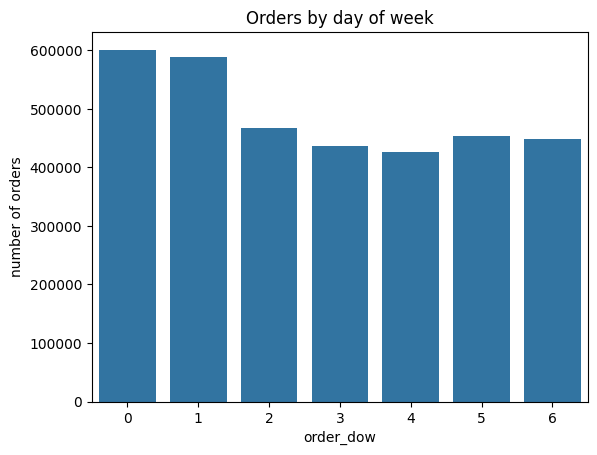

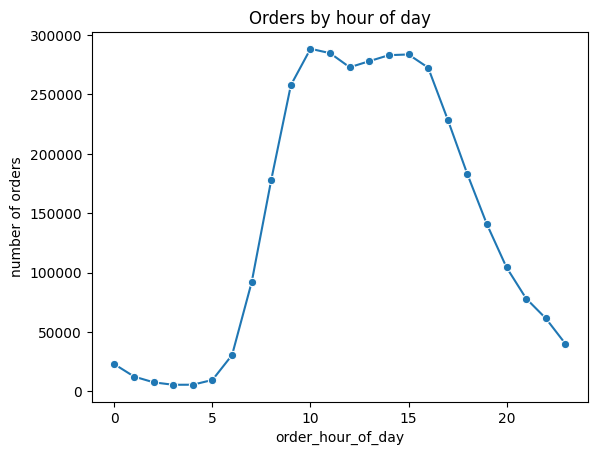

In [11]:
# Time patterns
plot_orders_by_day(orders)
plot_orders_by_hour(orders)

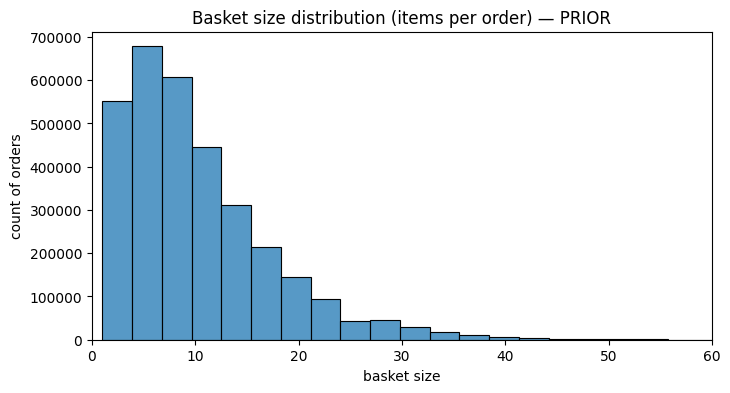

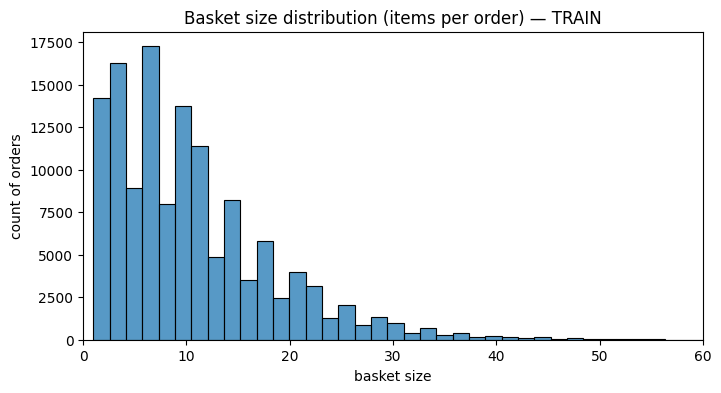

In [12]:
# Basket size distribution (prior and train)
plot_basket_size_distribution(op_prior, label="PRIOR", x_max=60)
plot_basket_size_distribution(op_train, label="TRAIN", x_max=60)

,product_id,product_name,department,aisle,n_purchases
24848,24852,Banana,produce,fresh fruits,472565
13172,13176,Bag of Organic Bananas,produce,fresh fruits,379450
21133,21137,Organic Strawberries,produce,fresh fruits,264683
21899,21903,Organic Baby Spinach,produce,packaged vegetables fruits,241921
47198,47209,Organic Hass Avocado,produce,fresh fruits,213584
47755,47766,Organic Avocado,produce,fresh fruits,176815
47615,47626,Large Lemon,produce,fresh fruits,152657
16793,16797,Strawberries,produce,fresh fruits,142951
26204,26209,Limes,produce,fresh fruits,140627
27839,27845,Organic Whole Milk,dairy eggs,milk,137905


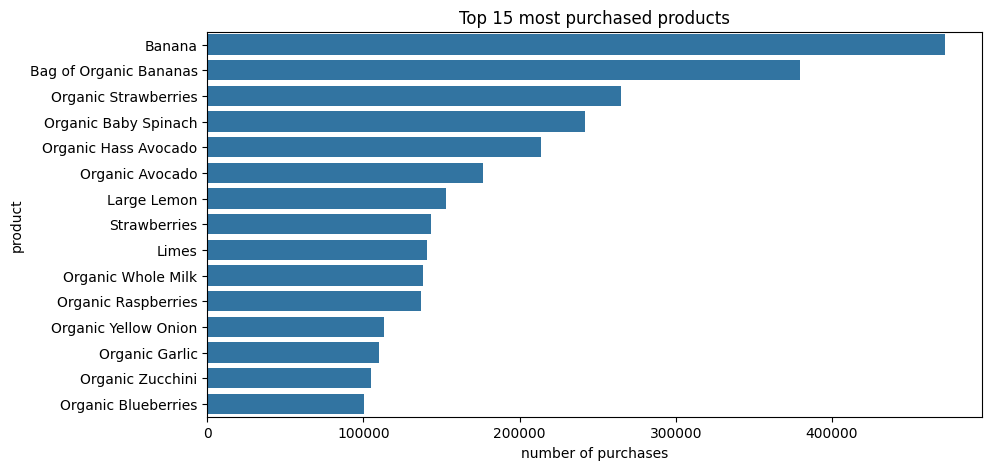

,product_id,product_name,department,aisle,n_purchases
28812,28818,Hot Oatmeal Multigrain Raisin,breakfast,hot cereal pancake mixes,1
7708,7712,String Of Pearl White Sprinkles,pantry,baking supplies decor,1
4414,4417,Organic Veggie Ground,deli,tofu meat alternatives,1
47397,47408,Control GX Gray Reducing Shampoo,missing,missing,1
14481,14485,Organic Ice Cream Birthday Cake,frozen,ice cream ice,1
16457,16461,Peas Pulav Basmati Rice With Green Peas,international,indian foods,1
2768,2769,Pappardelle Nests Pasta,dry goods pasta,dry pasta,1
24344,24348,Salted Caramel Craze Ice Cream,missing,missing,1
6317,6320,Spinach Cheese Rice Palak Paneer Dinner,frozen,frozen meals,1
34325,34331,Chelated Magnesium 250 Mg Gluten Free,personal care,vitamins supplements,1


,product_id,product_name,department,aisle,n_purchases
24848,24852,Banana,produce,fresh fruits,472565
13172,13176,Bag of Organic Bananas,produce,fresh fruits,379450
21133,21137,Organic Strawberries,produce,fresh fruits,264683
21899,21903,Organic Baby Spinach,produce,packaged vegetables fruits,241921
47198,47209,Organic Hass Avocado,produce,fresh fruits,213584
47755,47766,Organic Avocado,produce,fresh fruits,176815
47615,47626,Large Lemon,produce,fresh fruits,152657
16793,16797,Strawberries,produce,fresh fruits,142951
26204,26209,Limes,produce,fresh fruits,140627
27839,27845,Organic Whole Milk,dairy eggs,milk,137905


In [13]:
# Product popularity (prior)
prior_pop = product_popularity(op_prior, products_enriched)
display(prior_pop.head(10)[["product_id", "product_name", "department", "aisle", "n_purchases"]])

# Frequent products (top) + plot
plot_top_products(prior_pop, top_n=15)

# Rare products (bottom) - show table
show_rare_products(prior_pop, n=15)

# Outlier products (very frequent)
outliers = identify_outlier_products(prior_pop, q=0.99)
display(outliers.head(20)[["product_id", "product_name", "department", "aisle", "n_purchases"]])


,department,n_lines,share
19,produce,9479291,0.292260
7,dairy eggs,5414016,0.166922
20,snacks,2887550,0.089027
3,beverages,2690129,0.082940
10,frozen,2236432,0.068952
16,pantry,1875577,0.057827
2,bakery,1176787,0.036282
6,canned goods,1068058,0.032930
8,deli,1051249,0.032411
9,dry goods pasta,866627,0.026719


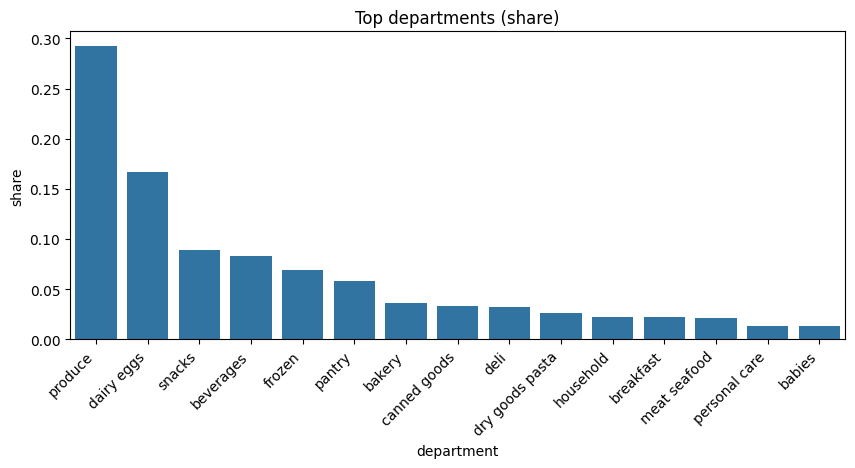

,aisle,n_lines,share
50,fresh fruits,3642188,0.112294
53,fresh vegetables,3418021,0.105382
98,packaged vegetables fruits,1765313,0.054427
133,yogurt,1452343,0.044778
93,packaged cheese,979763,0.030207
83,milk,891015,0.027471
131,water seltzer sparkling water,841533,0.025946
25,chips pretzels,722470,0.022275
119,soy lactosefree,638253,0.019678
11,bread,584834,0.018031


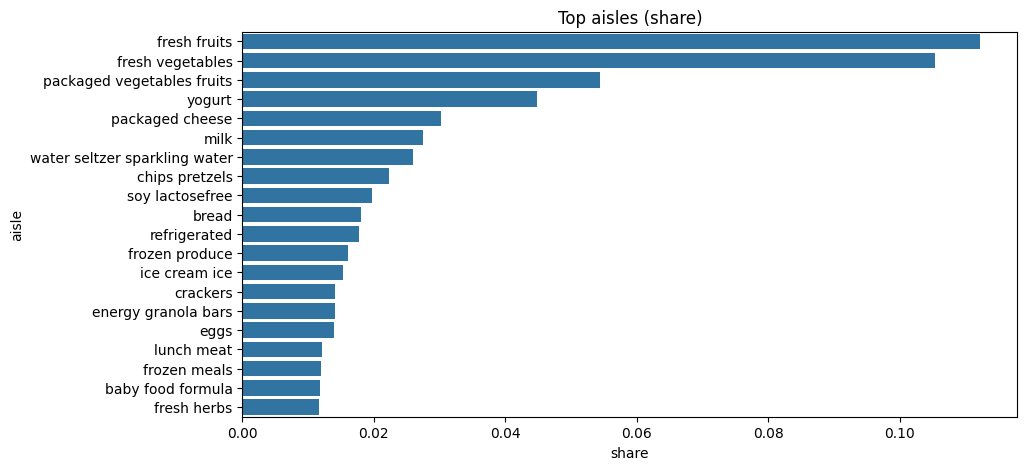

In [14]:
# Departments and aisles coverage in PRIOR (important before mining)
dep_prior = department_distribution(op_prior, products_enriched)
display(dep_prior.head(20))
plot_department_share(dep_prior, top_n=15)

ais_prior = aisle_distribution(op_prior, products_enriched, top_n=20)
display(ais_prior)
plot_aisle_share(ais_prior)

,department,n_lines,share
19,produce,409087,0.295451
7,dairy eggs,217051,0.156759
20,snacks,118862,0.085845
3,beverages,114046,0.082366
10,frozen,100426,0.072530
16,pantry,81242,0.058675
2,bakery,48394,0.034951
6,canned goods,46799,0.033799
8,deli,44291,0.031988
9,dry goods pasta,38713,0.027959


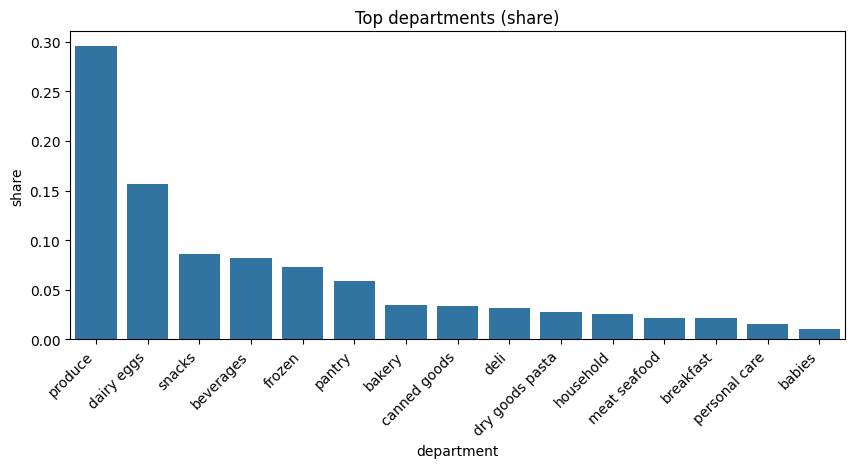

,aisle,n_lines,share
53,fresh vegetables,150609,0.108773
50,fresh fruits,150473,0.108675
98,packaged vegetables fruits,78493,0.056689
133,yogurt,55240,0.039896
93,packaged cheese,41699,0.030116
131,water seltzer sparkling water,36617,0.026446
83,milk,32644,0.023576
25,chips pretzels,31269,0.022583
119,soy lactosefree,26240,0.018951
11,bread,23635,0.017070


In [15]:
# Departments and aisles coverage in TRAIN (to compare)
dep_train = department_distribution(op_train, products_enriched)
display(dep_train.head(20))
plot_department_share(dep_train, top_n=15)

ais_train = aisle_distribution(op_train, products_enriched, top_n=20)
display(ais_train)

In [16]:
# Customer behavior: heavy vs light (prior features)
user_feat = build_user_features(orders, op_prior)
display(user_feat.describe())
show_heavy_users(user_feat, top_n=10)

,user_id,n_orders,n_items_prior,avg_basket_size,reorder_rate
count,206209.000000,206209.000000,206209.000000,206209.000000,206209.000000
mean,103105.000000,16.590367,157.289396,9.951586,0.432249
std,59527.555167,16.654774,204.208233,5.863570,0.212144
min,1.000000,4.000000,3.000000,1.000000,0.000000
25%,51553.000000,6.000000,39.000000,5.740741,0.267857
50%,103105.000000,10.000000,83.000000,8.933333,0.428571
75%,154657.000000,20.000000,188.000000,13.000000,0.595745
max,206209.000000,100.000000,3725.000000,70.250000,0.989529


,user_id,n_orders,n_items_prior,avg_basket_size,reorder_rate
201267,201268,100,3725,37.626263,0.879195
129927,129928,65,3638,56.843750,0.870533
164054,164055,100,3061,30.919192,0.868017
186703,186704,100,2936,29.656566,0.869550
176477,176478,100,2921,29.505051,0.831565
182400,182401,100,2907,29.363636,0.750258
137628,137629,100,2901,29.303030,0.902792
33730,33731,100,2888,29.171717,0.829986
108186,108187,60,2760,46.779661,0.886232
4693,4694,90,2735,30.730337,0.803656


In [17]:
# First vs last prior order products (simple "first vs last" check)
first_last = first_vs_last_prior_products(orders, op_prior, products_enriched, top_n=15)
display(first_last["first"][["product_name", "department", "aisle", "n_purchases"]])
display(first_last["last"][["product_name", "department", "aisle", "n_purchases"]])

,product_name,department,aisle,n_purchases
21023,Banana,produce,fresh fruits,29534
11029,Bag of Organic Bananas,produce,fresh fruits,19158
17865,Organic Strawberries,produce,fresh fruits,16464
40377,Organic Avocado,produce,fresh fruits,15187
18526,Organic Baby Spinach,produce,packaged vegetables fruits,14948
39893,Organic Hass Avocado,produce,fresh fruits,11106
14131,Strawberries,produce,fresh fruits,8660
22169,Limes,produce,fresh fruits,8598
40249,Large Lemon,produce,fresh fruits,8360
23538,Organic Whole Milk,dairy eggs,milk,7223


,product_name,department,aisle,n_purchases
21305,Banana,produce,fresh fruits,29414
11285,Bag of Organic Bananas,produce,fresh fruits,24093
18101,Organic Strawberries,produce,fresh fruits,15590
18783,Organic Baby Spinach,produce,packaged vegetables fruits,15410
40796,Large Lemon,produce,fresh fruits,12100
40430,Organic Hass Avocado,produce,fresh fruits,11561
40913,Organic Avocado,produce,fresh fruits,11545
14363,Strawberries,produce,fresh fruits,10012
22465,Limes,produce,fresh fruits,9187
23944,Organic Raspberries,produce,packaged vegetables fruits,8591
